In [2]:
import edes 
from edes.experiments import Experiment
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
from edes.experiments.sequences.base import TipVoltageSweep
big_plt_font()

In [3]:
exp = Experiment('3layer_trapping_052026')

>>> Connected to Agilent Technologies,34461A,MY53200916,A.01.08-02.22-00.08-00.35-01-01

>>> Connected to RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19

>>> Connected to KEITHLEY INSTRUMENTS INC.,MODEL 2100,1,01.07-01-01
>>> Connected to Siglent Technologies,SPD3303X-E,SPD3XJEQ6R3773,1.01.01.02.07R2,V3.0

>>> Connected to Siglent Technologies,SSA3032X-R,SSA5PA1Q800415,3.2.2.6.0R10

>>> ERROR initializing device Valon: ('VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.', 'setting Valon_frequency to 1472114285')


In [4]:
exp.list_devices()

['Agilent', 'FEtip_PSU', 'Keithley', 'LNA_PSU', 'SSA']

In [6]:
tip_Vsweep = TipVoltageSweep(saving_dir=exp.saving_dir, 
                             V_start=1000, V_stop=3000, V_step=200, R=100e6, 
                             N_avg=8, t_PSU_settle=2, t_meas_delay=0.2, 
                             FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Agilent)

In [7]:
file = tip_Vsweep.run_save()

100%|███████████████████████████████████████████| 10/10 [01:05<00:00,  6.55s/it]


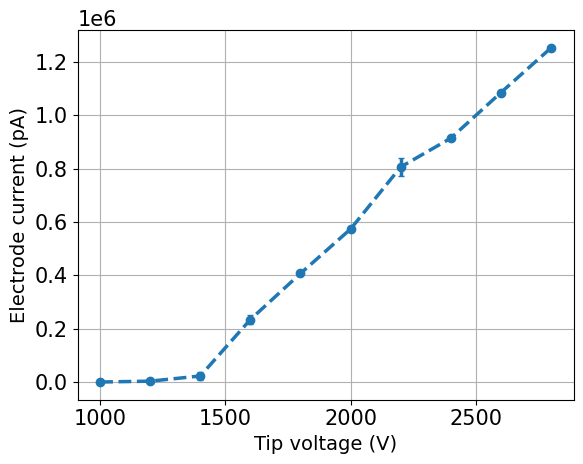

In [8]:
plot_errbar(file['all_V'], -np.mean(file['all_I'], axis=1)*1e12, yerr=np.std(file['all_I'], axis=1)*1e12, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (pA)')
# plt.yscale('log')

In [3]:
tip_Vsweep = TipVoltageSweep(saving_dir=exp.saving_dir, 
                             V_start=1000, V_stop=3000, V_step=200, R=100e6, 
                             N_avg=3, t_PSU_settle=5, t_meas_delay=2, 
                             FEtip_PSU=exp.FEtip_PSU, multimeter=exp.Keithley)

In [4]:
file = tip_Vsweep.run_save()

100%|███████████████████████████████████████████| 10/10 [01:50<00:00, 11.09s/it]


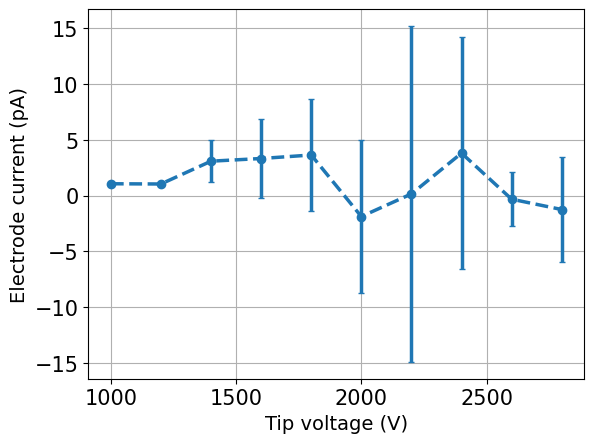

In [5]:
plot_errbar(file['all_V'], -np.mean(file['all_I'], axis=1)*1e12, yerr=np.std(file['all_I'], axis=1)*1e12, fmt='.--', xlabel='Tip voltage (V)', ylabel='Electrode current (pA)')
# plt.yscale('log')

In [7]:
exp.Keithley.close()

In [8]:
exp.load_device("Keithley")

>>> Connected to KEITHLEY INSTRUMENTS INC.,MODEL 2100,1,01.07-01-01
